# Regression trees with c50py: house prices on mixed data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daviddiazsolis/c50py/blob/main/examples/notebooks/06_regression_house_prices.ipynb)

`C5Regressor` brings the C5.0 way of treating categories and missing values to regression: the
target is a number (a price, a spend, a loss) instead of a class. This notebook uses the Ames
house prices data (1,460 houses sold in Ames, Iowa, 2006 to 2010; 79 columns, 43 of them
categorical, 19 with gaps) and compares `C5Regressor` with scikit-learn's regression tree and
with gradient boosting.

A word on names first. C5.0 itself only builds classification trees; for numeric targets Quinlan
wrote other programs (M5 and Cubist). `C5Regressor` is a regression tree that keeps what
distinguishes C5.0 from CART on the input side: categorical splits that group categories, and
cases with missing values sent down both branches with fractional weights. Its split criterion is
the usual one for regression trees, the reduction of squared error.

In [1]:
# Colab / a fresh environment: install c50py (0.5.1 or later)
import importlib, subprocess, sys
try:
    import c50py
    assert tuple(int(v) for v in c50py.__version__.split(".")[:3]) >= (0, 5, 1)
except (ImportError, AssertionError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "c50py>=0.5.1"], check=True)
    import c50py
    importlib.reload(c50py)
print("c50py", c50py.__version__)

c50py 0.5.1


In [2]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.tree import DecisionTreeRegressor
from c50py import C5Regressor

ames = fetch_openml(data_id=42165, as_frame=True, parser="pandas")     # "house_prices"
X = ames.data.drop(columns=["Id"])
for c in X.columns:
    if str(X[c].dtype) in ("object", "str", "string", "bool"):
        X[c] = X[c].astype("category")
y = np.log(ames.target.astype(float).to_numpy())       # log of the sale price
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
cats = [c for c in X.columns if str(X[c].dtype) == "category"]
print(X.shape, f" categorical columns: {len(cats)}   columns with gaps: {int(X.isna().any().sum())}")

(1460, 79)  categorical columns: 43   columns with gaps: 19


We model the **logarithm** of the price. Errors in logs read as percentages: a root mean squared
error (RMSE) of 0.15 means a typical error of about 15% of the price, whatever the price level.

## 1. How a regression tree chooses a split

A leaf predicts the (weighted) mean of its training cases. A split is good if the two groups it
creates are each more homogeneous than the node it splits. The measure is the **reduction of the
sum of squared errors** (the criterion of CART regression trees, Breiman et al., 1984):

$$\Delta\text{SSE} = \text{SSE}(S) - \text{SSE}(S_L) - \text{SSE}(S_R), \qquad \text{SSE}(S) = \sum_{i \in S} w_i\,(y_i - \bar{y}_S)^2$$

- $S$: the training cases in the node; $S_L$ and $S_R$: those sent left and right by the split.
- $y_i$: the target of case $i$ (here, the log price); $w_i$: its weight (1 unless `sample_weight`
  is given; a fraction for cases with a missing value, see below).
- $\bar{y}_S$: the weighted mean of $y$ in $S$, which is what a leaf on $S$ would predict.

In words: *how much of the squared error of predicting one price for the whole node disappears
if we predict one price for each side.* At the root of this data the SSE is about 165 (1,022
houses times a variance of the log price of about 0.16), and the best first split, on the overall
quality of the house, brings it down to about 91: almost half of it is gone.

Three things differ from scikit-learn's `DecisionTreeRegressor`:

- **Categories.** A categorical column is split into two groups of categories (`Neighborhood IN
  {NoRidge, NridgHt, StoneBr}`), not one dummy at a time. Up to 12 categories every grouping is
  evaluated; with more, the categories are sorted by their mean target and only cuts of that
  ordered list are evaluated, which finds the best grouping for squared error (Fisher, 1958).
- **Missing values.** A house with no recorded `LotFrontage` goes down both branches of a test on
  it, with weights proportional to the known houses on each side, in training and in prediction.
- **Size control.** A split must leave at least `min_samples_leaf` of weight on each side, and a
  bottom-up pruning removes splits that do not reduce the squared error enough. That pruning is
  mild, so `min_samples_leaf` is the parameter to tune.

## 2. Five models

* `C5Regressor()`: defaults, no preprocessing.
* `C5Regressor`, `min_samples_leaf` chosen by 5-fold cross-validation.
* `DecisionTreeRegressor()` with scikit-learn's defaults, after one-hot encoding the categories
  (with "missing" as one more category) and filling numeric gaps with the training median.
* The same, with `ccp_alpha` and `min_samples_leaf` chosen by cross-validation.
* `HistGradientBoostingRegressor` with native categorical support: the accuracy benchmark.

In [3]:
def prepare_for_sklearn(D, columns=None, medians=None):
    D = D.copy()
    for c in cats:
        D[c] = D[c].astype(object).where(D[c].notna(), "missing")
    D = pd.get_dummies(D, columns=cats, dtype=int)
    if columns is not None:
        D = D.reindex(columns=columns, fill_value=0)
    medians = D.median() if medians is None else medians
    return D.fillna(medians), medians

A_train, medians = prepare_for_sklearn(X_train)
A_test, _ = prepare_for_sklearn(X_test, A_train.columns, medians)
print("columns for scikit-learn after one-hot encoding:", A_train.shape[1], "  for c50py:", X_train.shape[1])

cv = KFold(5, shuffle=True, random_state=0)

def leaves(m):
    return m.tree_.n_leaves if isinstance(m, C5Regressor) else (m.get_n_leaves() if hasattr(m, "get_n_leaves") else None)

path = DecisionTreeRegressor(random_state=0).cost_complexity_pruning_path(A_train, y_train)
alphas = np.unique(np.quantile(path.ccp_alphas, np.linspace(0, 0.98, 25)))
candidates = [
    ("c50py, defaults", lambda: C5Regressor(), "raw"),
    ("c50py, min_samples_leaf tuned by CV",
     lambda: GridSearchCV(C5Regressor(), {"min_samples_leaf": [2, 5, 10, 20, 40]}, cv=cv), "raw"),
    ("CART + one-hot, defaults", lambda: DecisionTreeRegressor(random_state=0), "onehot"),
    ("CART + one-hot, tuned by CV",
     lambda: GridSearchCV(DecisionTreeRegressor(random_state=0),
                          {"ccp_alpha": alphas, "min_samples_leaf": [1, 5, 10, 20, 40]}, cv=cv), "onehot"),
    ("HistGradientBoosting", lambda: HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=0), "raw"),
]
rows, fitted = [], {}
for label, make, data in candidates:
    Xa, Xb = (X_train, X_test) if data == "raw" else (A_train, A_test)
    t0 = time.time()
    m = make().fit(Xa, y_train)
    seconds = time.time() - t0
    m = getattr(m, "best_estimator_", m)
    fitted[label] = m
    pred = m.predict(Xb)
    rows.append(dict(model=label, R2=1 - np.sum((y_test - pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2),
                     RMSE_log=np.sqrt(np.mean((y_test - pred) ** 2)), leaves=leaves(m), seconds=seconds))
results = pd.DataFrame(rows).round(3)
results

columns for scikit-learn after one-hot encoding: 296   for c50py: 79


,model,R2,RMSE_log,leaves,seconds
0,"c50py, defaults",0.732,0.203,444.0,15.420
1,"c50py, min_samples_leaf tuned by CV",0.794,0.178,78.0,55.160
2,"CART + one-hot, defaults",0.757,0.194,992.0,0.042
3,"CART + one-hot, tuned by CV",0.787,0.181,39.0,17.131
4,HistGradientBoosting,0.891,0.130,NaN,0.424


In [4]:
print("min_samples_leaf chosen for c50py:", fitted["c50py, min_samples_leaf tuned by CV"].min_samples_leaf)
best_cart = fitted["CART + one-hot, tuned by CV"]
print("CART tuned:", {"ccp_alpha": round(best_cart.ccp_alpha, 5), "min_samples_leaf": best_cart.min_samples_leaf})

min_samples_leaf chosen for c50py: 10
CART tuned: {'ccp_alpha': np.float64(0.0), 'min_samples_leaf': 20}


How to read the table:

* **With their defaults both trees grow until the leaves are tiny** and overfit; neither default
  is a sensible model for this data. scikit-learn's grows to several hundred leaves more.
* **Tuned, the two trees are close in accuracy.** One test split of 438 houses cannot separate
  them: a difference of a hundredth in R² is a few houses priced a little better or worse.
* **Gradient boosting is clearly more accurate** (an RMSE of about 13% against about 18% for the
  tuned trees). House
  prices are a smooth sum of many effects (size, quality, age, location), which hundreds of small
  trees capture and one tree can only approximate with steps. If the goal is the most accurate
  price, use the ensemble.
* **Where c50py is different is the input and the output**: 79 columns as they come against 296
  one-hot columns plus imputation, and rules stated in the data's own terms.

## 3. The rule behind each price

Every prediction of a regression tree is the mean price of one leaf, so every price has a rule.
`predict_rule` returns it. The prediction is in logs; `np.exp` turns it back into dollars.

In [5]:
tree = fitted["c50py, min_samples_leaf tuned by CV"]
sample = X_test.head(4)
pd.set_option("display.max_colwidth", 200)
pd.DataFrame({
    "predicted price": np.exp(tree.predict(sample)).round(-3),
    "actual price": np.exp(y_test[:4]).round(-3),
    "rule": tree.predict_rule(sample),
}, index=sample.index)

,predicted price,actual price,rule
529,235000.0,201000.0,"OverallQual <= 6.5 AND Neighborhood NOT IN {BrDale, BrkSide, Edwards, IDOTRR, MeadowV, OldTown} AND GrLivArea > 1149 AND Neighborhood NOT IN {Blueste, Mitchel, NAmes, NPkVill, SWISU, Sawyer, Sawye..."
491,126000.0,133000.0,"OverallQual <= 6.5 AND Neighborhood NOT IN {BrDale, BrkSide, Edwards, IDOTRR, MeadowV, OldTown} AND GrLivArea > 1149 AND Neighborhood IN {Blueste, Mitchel, NAmes, NPkVill, SWISU, Sawyer, SawyerW} ..."
459,93000.0,110000.0,"OverallQual <= 6.5 AND Neighborhood IN {BrDale, BrkSide, Edwards, IDOTRR, MeadowV, OldTown} AND GrLivArea > 1114.5 AND LotArea <= 9921.5 AND OverallCond <= 4.5"
279,198000.0,192000.0,"OverallQual > 6.5 AND OverallQual <= 7.5 AND GrLivArea > 1822 AND BsmtFinSF1 <= 952 AND Neighborhood IN {BrkSide, ClearCr, CollgCr, Gilbert, Mitchel, NAmes, NWAmes, OldTown, SawyerW, StoneBr, Timb..."


An appraiser can check each rule against the house: the neighbourhood group, the overall quality,
the living area. The first tests of the tree are also a ranking of what drives prices in this
market:

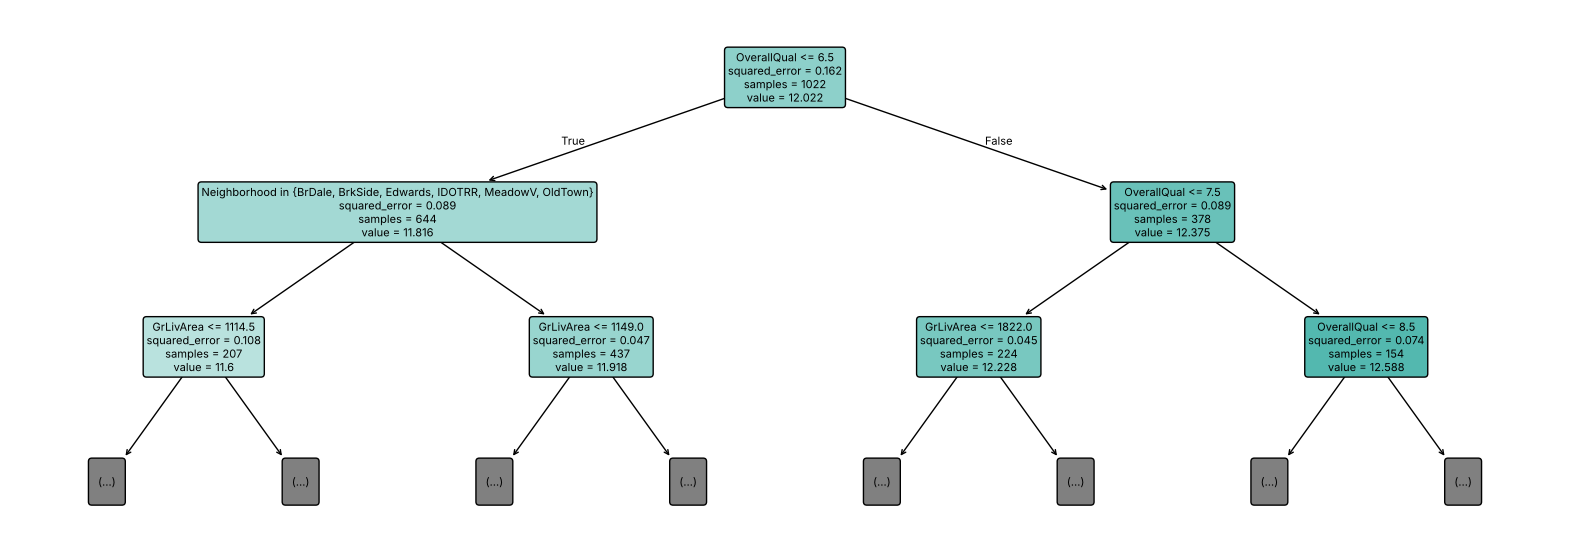

In [6]:
fig, ax = plt.subplots(figsize=(20, 7))
tree.plot_tree(max_depth=2, filled=True, rounded=True, fontsize=8, ax=ax)
plt.show()

## 4. One question instead of a staircase

The difference in the trees shows best on a small example. 2,000 simulated sales in 12
neighbourhoods; three of them are 40% more expensive, and the price also grows with the area. The
true structure is one question about the neighbourhood and one about the area.

In [7]:
rng = np.random.default_rng(3)
n = 2000
hoods = [f"hood_{c}" for c in "ABCDEFGHIJKL"]
toy = pd.DataFrame({"neighbourhood": pd.Categorical(rng.choice(hoods, n)),
                    "area_m2": rng.uniform(50, 250, n).round()})
premium = toy.neighbourhood.isin(["hood_C", "hood_G", "hood_K"])
toy_y = np.log(1000 * toy.area_m2) + np.where(premium, np.log(1.4), 0) + rng.normal(0, 0.1, n)
T_train, T_test, t_train, t_test = train_test_split(toy, toy_y, test_size=0.3, random_state=0)

c5_toy = C5Regressor(min_samples_leaf=50).fit(T_train, t_train)
cart_toy = DecisionTreeRegressor(min_samples_leaf=50, random_state=0).fit(pd.get_dummies(T_train, dtype=int), t_train)
print(f"c50py:          {c5_toy.tree_.n_leaves} leaves, test R2 {c5_toy.score(T_test, t_test):.3f}")
print(f"CART + one-hot: {cart_toy.get_n_leaves()} leaves, test R2 {cart_toy.score(pd.get_dummies(T_test, dtype=int), t_test):.3f}")
def tests_on_neighbourhood_c50(node):
    if node.is_leaf or not node.children:
        return 0
    here = int(c5_toy.feature_names_[node.feature_index] == "neighbourhood")
    return here + sum(tests_on_neighbourhood_c50(ch) for ch in node.children.values())

dummy_names = list(pd.get_dummies(T_train, dtype=int).columns)
cart_tests = sum(1 for f in cart_toy.tree_.feature if f >= 0 and dummy_names[f].startswith("neighbourhood"))
print(f"\ntests on the neighbourhood: c50py {tests_on_neighbourhood_c50(c5_toy.tree_)}, CART {cart_tests}")
print("a c50py rule:", [r for r in c5_toy.export_rules() if "neighbourhood IN" in r][0])

c50py:          21 leaves, test R2 0.941
CART + one-hot: 21 leaves, test R2 0.859

tests on the neighbourhood: c50py 5, CART 0
a c50py rule: area_m2 <= 122.5 AND area_m2 <= 85.5 AND neighbourhood IN {hood_C, hood_G, hood_K} => value=11.4102 (N=71.00)


Same number of leaves, and a large difference in accuracy. Both trees cut the area into steps,
which is what a tree does with a continuous effect. The difference is the neighbourhood. For
CART each dummy column separates one twelfth of the houses, and a step in the area always reduces
the error more, so it never asks about the neighbourhood at all: the 40% premium is lost. c50py
groups the three premium neighbourhoods in a single test and uses it within each range of area.
This is the same mechanism as the staircase of notebook 02, and it matters most when a category
with many values carries the signal.

## 5. Summary

* `C5Regressor` fits mixed tables as they come: categorical columns grouped in one test, missing
  values handled without imputation.
* Its accuracy is close to a scikit-learn regression tree of similar size; tune `min_samples_leaf`
  by cross-validation, since the defaults grow a large tree.
* For the most accurate predictions use gradient boosting; use `C5Regressor` when the rule behind
  each prediction has to be read, explained or audited.